In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "utils.py").exists() and (ROOT.parent / "src" / "utils.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import DATA_CLEANED, load_jsonl

pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")




In [ ]:
TICKERS = ["NVDA", "MSFT", "AAPL", "AMZN", "GOOGL", "META", "TSLA"]
SENTIMENT_COLS = [
    "sentiment_vader",
    "sentiment_llm_phi3",
    "sentiment_llm_llama3_2",
    "sentiment_llm_deepseek_r1",
]

In [ ]:
path = DATA_CLEANED / "processed_master_orig.jsonl"
rows = load_jsonl(path)
df = pd.DataFrame(rows)

,posted_at,fetched_at,headline,url,source,reporter,ticker,is_ai_related,is_proxy_partnership,sentiment_vader,sentiment_llm_phi3,sentiment_llm_llama3_2,sentiment_llm_deepseek_r1
0,2026-02-23T21:47:00Z,2026-02-26T15:43:31Z,AirPods as Apple’s first AI wearable product makes so much sense - 9to5Mac,https://9to5mac.com/2026/02/23/airpods-as-apples-first-ai-wearable-product-makes-so-much-sense/,NewsAPI Tech,9to5Mac,AAPL,True,False,0.000,0.80,0.4,0.7
1,2026-02-24T05:45:00Z,2026-02-26T15:43:31Z,Gemini 3.1 Pro is a powerhouse for deep work — here are 7 prompts that prove it - Tom's Guide,https://www.tomsguide.com/ai/gemini-3-1-pro-is-a-powerhouse-for-deep-work-here-are-7-prompts-that-prove-it,NewsAPI Tech,Tom's Guide,GOOGL,True,False,0.000,0.60,0.4,0.0
2,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,AAPL,True,True,0.000,0.60,0.4,0.9
3,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,GOOGL,True,False,0.000,0.60,0.4,0.9
4,2026-02-24T17:30:10Z,2026-02-26T15:43:31Z,Microsoft adds Copilot data controls to all storage locations - BleepingComputer,https://www.bleepingcomputer.com/news/microsoft/microsoft-adds-copilot-data-controls-to-all-storage-locations/,NewsAPI Tech,BleepingComputer,MSFT,True,False,0.000,0.60,-0.4,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,2026-03-17T18:48:35Z,2026-03-17T22:41:47Z,Exclusive: Amazon CEO sees AI doubling prior AWS sales projections to $600 billion by 2036 - Reuters,https://news.google.com/rss/articles/CBMiwgFBVV95cUxPakt6S3Bjbm5pMVh3blpDZ3JrdUdCQXNETjBlZlRTQURrbTJDb3FpbmN6YzdVRlpGWnVBaklOSkxNcWlOdWlWS20tZ2Vyakt5UTktWFhxSnYxZHp1TkJ3dFRTbEUxcnVYM055UC1fb3FMbmVSbFRlc3NjMVNrRF9waU9GS2w4VUtfQkh0U0ZzaHJYOHpmdEtZYU9rMjk3Y3Q4M3pjWkFjQWV1RmhHZ0hvU1NCT3pNaWlWalZ5bmhTSjhodw?oc=5,Google News RSS,Reuters,AMZN,True,False,0.296,0.85,0.8,0.0
922,2026-03-17T21:00:00Z,2026-03-17T22:41:47Z,"Mistral bets on ‘build-your-own AI’ as it takes on OpenAI, Anthropic in the enterprise",https://techcrunch.com/2026/03/17/mistral-forge-nvidia-gtc-build-your-own-ai-enterprise/,TechCrunch,TechCrunch,AAPL,True,True,0.000,0.60,0.4,0.7
923,2026-03-17T21:00:00Z,2026-03-17T22:41:47Z,"Mistral bets on ‘build-your-own AI’ as it takes on OpenAI, Anthropic in the enterprise",https://techcrunch.com/2026/03/17/mistral-forge-nvidia-gtc-build-your-own-ai-enterprise/,TechCrunch,TechCrunch,AMZN,True,True,0.000,0.60,0.4,0.7
924,2026-03-17T21:00:00Z,2026-03-17T22:41:47Z,"Mistral bets on ‘build-your-own AI’ as it takes on OpenAI, Anthropic in the enterprise",https://techcrunch.com/2026/03/17/mistral-forge-nvidia-gtc-build-your-own-ai-enterprise/,TechCrunch,TechCrunch,MSFT,True,True,0.000,0.60,0.4,0.7


In [13]:
df.dtypes

posted_at                        str
fetched_at                       str
headline                         str
url                              str
source                           str
reporter                         str
ticker                           str
is_ai_related                   bool
is_proxy_partnership            bool
sentiment_vader              float64
sentiment_llm_phi3           float64
sentiment_llm_llama3_2       float64
sentiment_llm_deepseek_r1    float64
dtype: object

In [14]:
filtered_df = df[df["is_ai_related"] == True]
filtered_df = filtered_df.drop_duplicates(
    subset=["posted_at", "url", "ticker", "sentiment_vader", "sentiment_llm_phi3",
            "sentiment_llm_llama3_2", "sentiment_llm_deepseek_r1"]
)

In [25]:
filtered_df.head()

,posted_at,fetched_at,headline,url,source,reporter,ticker,is_ai_related,is_proxy_partnership,sentiment_vader,sentiment_llm_phi3,sentiment_llm_llama3_2,sentiment_llm_deepseek_r1
0,2026-02-23T21:47:00Z,2026-02-26T15:43:31Z,AirPods as Apple’s first AI wearable product makes so much sense - 9to5Mac,https://9to5mac.com/2026/02/23/airpods-as-apples-first-ai-wearable-product-makes-so-much-sense/,NewsAPI Tech,9to5Mac,AAPL,True,False,0.0,0.8,0.4,0.7
1,2026-02-24T05:45:00Z,2026-02-26T15:43:31Z,Gemini 3.1 Pro is a powerhouse for deep work — here are 7 prompts that prove it - Tom's Guide,https://www.tomsguide.com/ai/gemini-3-1-pro-is-a-powerhouse-for-deep-work-here-are-7-prompts-that-prove-it,NewsAPI Tech,Tom's Guide,GOOGL,True,False,0.0,0.6,0.4,0.0
2,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,AAPL,True,True,0.0,0.6,0.4,0.9
3,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,GOOGL,True,False,0.0,0.6,0.4,0.9
4,2026-02-24T17:30:10Z,2026-02-26T15:43:31Z,Microsoft adds Copilot data controls to all storage locations - BleepingComputer,https://www.bleepingcomputer.com/news/microsoft/microsoft-adds-copilot-data-controls-to-all-storage-locations/,NewsAPI Tech,BleepingComputer,MSFT,True,False,0.0,0.6,-0.4,0.5


In [27]:
df_ts = filtered_df.copy()
df_ts["posted_at"] = pd.to_datetime(df_ts["posted_at"], utc=True, errors="coerce")
df_ts["date"] = df_ts["posted_at"].dt.tz_convert(None).dt.normalize()
df_ts.head()

,posted_at,fetched_at,headline,url,source,reporter,ticker,is_ai_related,is_proxy_partnership,sentiment_vader,sentiment_llm_phi3,sentiment_llm_llama3_2,sentiment_llm_deepseek_r1,date
0,2026-02-23 21:47:00+00:00,2026-02-26T15:43:31Z,AirPods as Apple’s first AI wearable product makes so much sense - 9to5Mac,https://9to5mac.com/2026/02/23/airpods-as-apples-first-ai-wearable-product-makes-so-much-sense/,NewsAPI Tech,9to5Mac,AAPL,True,False,0.0,0.8,0.4,0.7,2026-02-23
1,2026-02-24 05:45:00+00:00,2026-02-26T15:43:31Z,Gemini 3.1 Pro is a powerhouse for deep work — here are 7 prompts that prove it - Tom's Guide,https://www.tomsguide.com/ai/gemini-3-1-pro-is-a-powerhouse-for-deep-work-here-are-7-prompts-that-prove-it,NewsAPI Tech,Tom's Guide,GOOGL,True,False,0.0,0.6,0.4,0.0,2026-02-24
2,2026-02-24 16:57:21+00:00,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,AAPL,True,True,0.0,0.6,0.4,0.9,2026-02-24
3,2026-02-24 16:57:21+00:00,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,GOOGL,True,False,0.0,0.6,0.4,0.9,2026-02-24
4,2026-02-24 17:30:10+00:00,2026-02-26T15:43:31Z,Microsoft adds Copilot data controls to all storage locations - BleepingComputer,https://www.bleepingcomputer.com/news/microsoft/microsoft-adds-copilot-data-controls-to-all-storage-locations/,NewsAPI Tech,BleepingComputer,MSFT,True,False,0.0,0.6,-0.4,0.5,2026-02-24


In [50]:
daily = (
    df_ts.groupby(["ticker", "date"], as_index=False)
         .agg(
             headline_count=("headline", "count"),
             vader_avg=("sentiment_vader", "mean"),
             phi3_avg=("sentiment_llm_phi3", "mean"),
             llama3_avg=("sentiment_llm_llama3_2", "mean"),
             deepseek_avg=("sentiment_llm_deepseek_r1", "mean"),
         )
         .sort_values(["ticker", "date"])
)
avg_cols = ["vader_avg", "phi3_avg", "llama3_avg", "deepseek_avg"]

daily = daily.sort_values(["ticker", "date"])
daily[avg_cols] = daily.groupby("ticker")[avg_cols].ffill()

daily['phi_delta'] = daily['phi3_avg'] - daily['vader_avg']
daily['llama_delta'] = daily['llama3_avg'] - daily['vader_avg']
daily['deepseek_delta'] = daily['deepseek_avg'] - daily['vader_avg']
daily['delta_sum'] = abs(daily['phi_delta']) + abs(daily['llama_delta']) + abs(daily['deepseek_delta'])

daily.head()



,ticker,date,headline_count,vader_avg,phi3_avg,llama3_avg,deepseek_avg,phi_delta,llama_delta,deepseek_delta,delta_sum
0,AAPL,2026-02-23,1,0.000000,0.800000,0.400000,0.700000,0.800000,0.400000,0.700000,1.900000
1,AAPL,2026-02-24,3,-0.098667,0.133333,-0.033333,0.700000,0.232000,0.065333,0.798667,1.096000
2,AAPL,2026-02-25,4,-0.100475,0.225000,0.075000,0.133333,0.325475,0.175475,0.233808,0.734758
3,AAPL,2026-02-26,5,0.148120,0.640000,0.480000,0.300000,0.491880,0.331880,0.151880,0.975640
4,AAPL,2026-02-27,12,-0.054292,-0.025000,-0.050000,-0.170000,0.029292,0.004292,-0.115708,0.149292


In [51]:
daily.isna().sum()

ticker            0
date              0
headline_count    0
vader_avg         0
phi3_avg          0
llama3_avg        0
deepseek_avg      0
phi_delta         0
llama_delta       0
deepseek_delta    0
delta_sum         0
dtype: int64

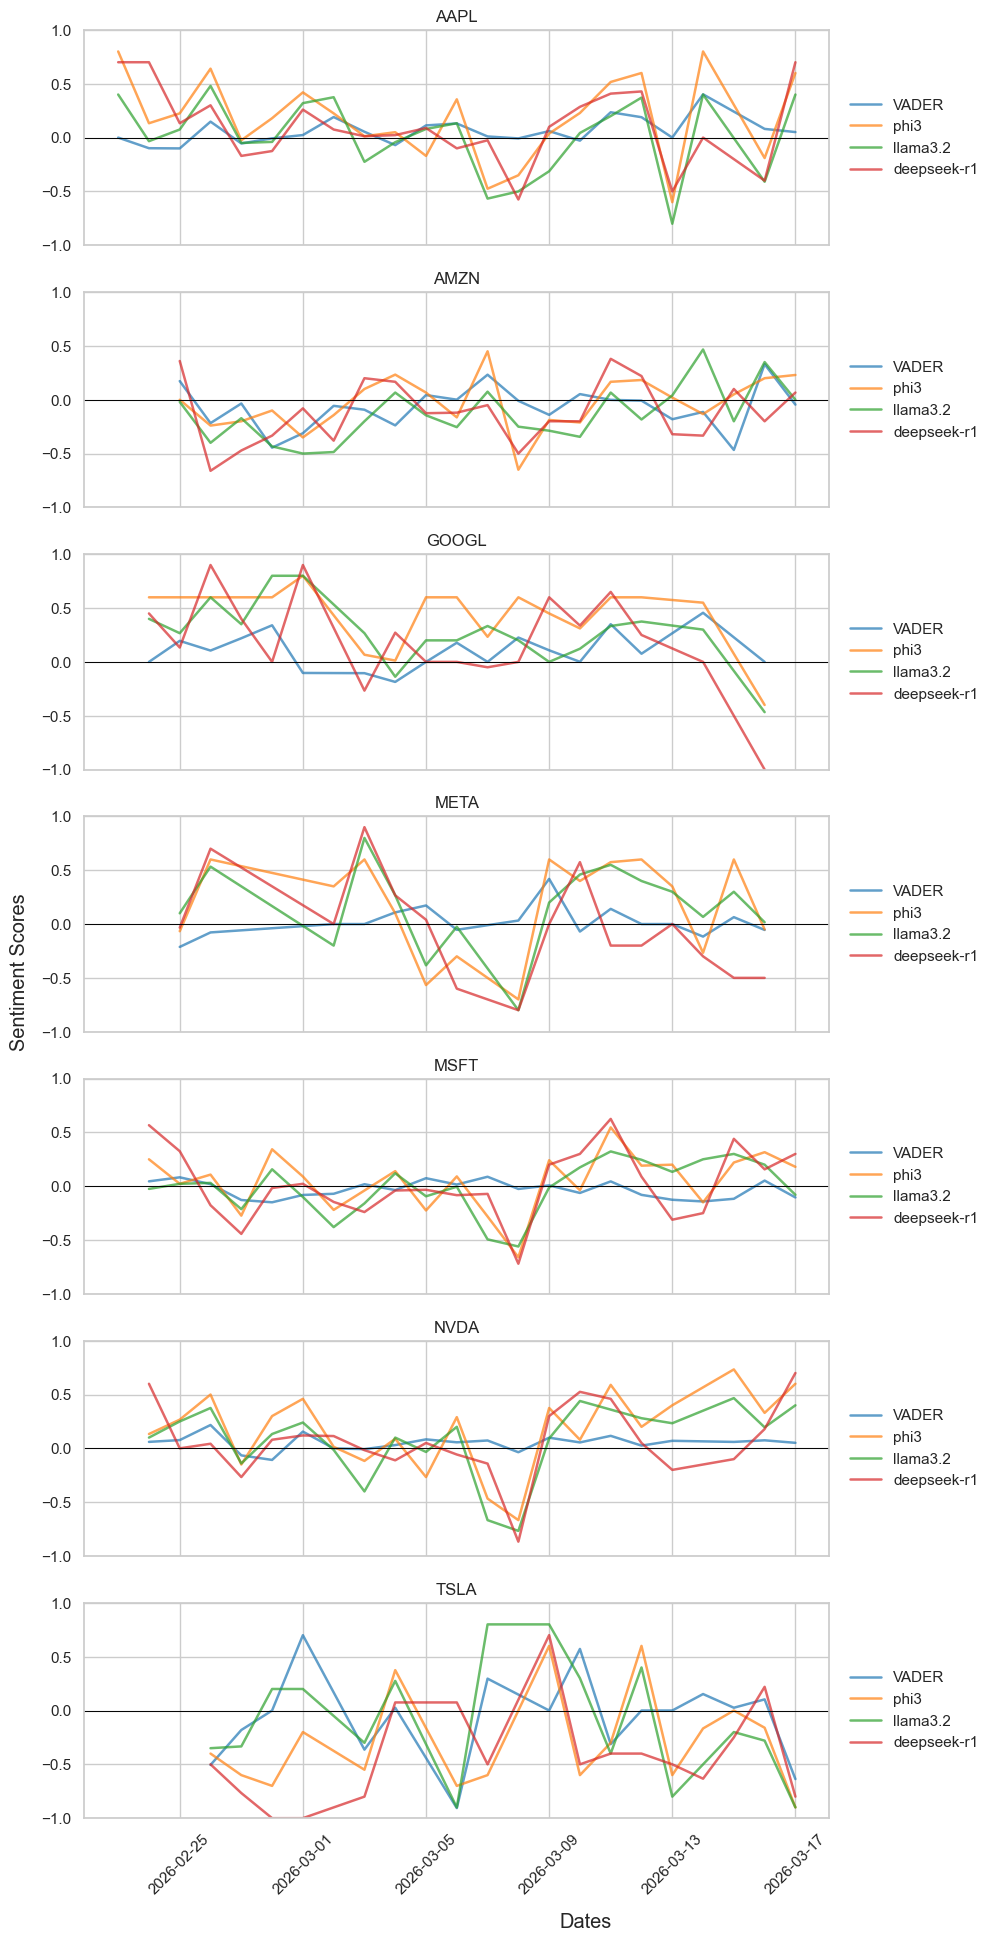

In [61]:
tickers = sorted(daily["ticker"].unique())
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 2.8 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

sentiment_cols = [
    ("vader_avg", "VADER", "tab:blue"),
    ("phi3_avg", "phi3", "tab:orange"),
    ("llama3_avg", "llama3.2", "tab:green"),
    ("deepseek_avg", "deepseek-r1", "tab:red"),
]

for ax, t in zip(axes, tickers):
    sub = daily[daily["ticker"] == t].sort_values("date")
    if sub.empty:
        continue

    for col_name, label, color in sentiment_cols:
        if col_name in sub.columns:
            ax.plot(sub["date"], sub[col_name],
                    label=label, color=color, alpha=0.7, linewidth=1.8)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_ylim(-1, 1)
    ax.set_title(t)
    ax.tick_params(axis="x", rotation=45)

    # legend to the right of this subplot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=False,
    )

fig.supxlabel("Dates")
fig.supylabel("Sentiment Scores")

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave room on right for legends
plt.show()

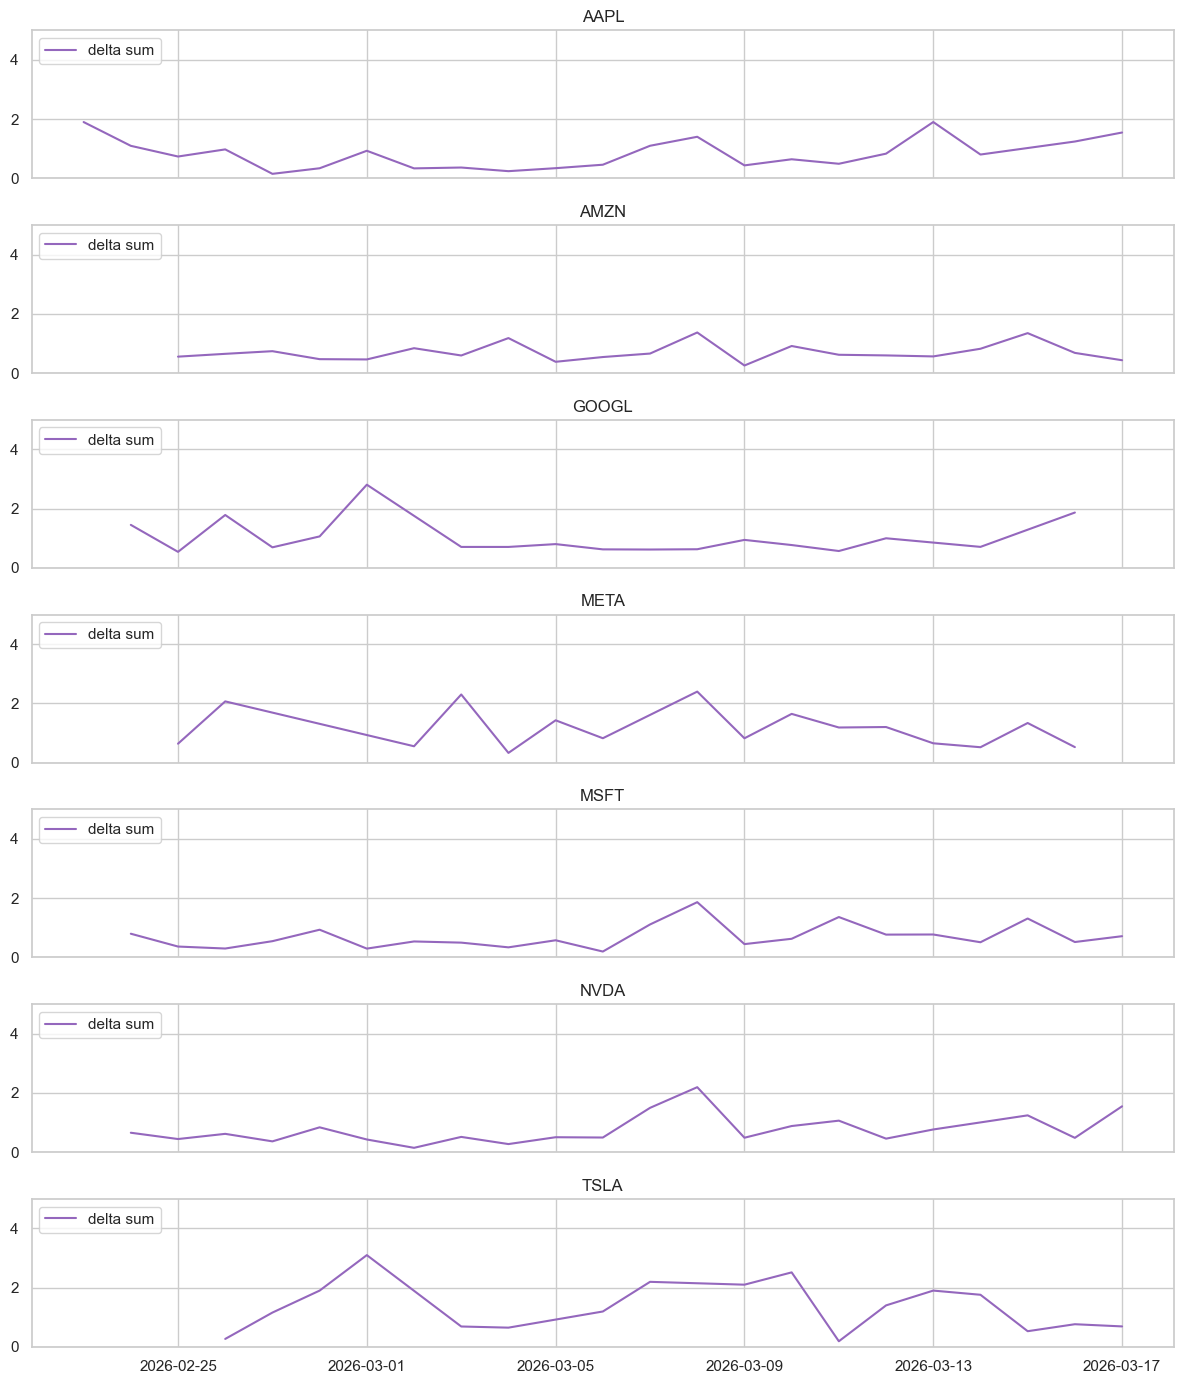

In [56]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 2.0 * len(tickers)), sharex=True)

if len(tickers) == 1:
    axes = [axes]

for ax, t in zip(axes, tickers):
    sub = daily[daily["ticker"] == t]
    if sub.empty:
        continue

    ax.plot(sub["date"], sub["delta_sum"], label="delta sum", color="tab:purple")
    ax.set_title(t)
    ax.legend(loc="upper left")
    ax.set_ylim(0, 5)  
plt.tight_layout()
plt.show()